In [1]:
import numpy as np
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import warnings
import pickle as pkl
import os
warnings.simplefilter("ignore")


In [2]:
from mtu_plots import graph_metrics_and_models, transform_relative_to_ideal
print(matplotlib.__version__)

3.6.3


In [3]:
DEBUG = True

In [4]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})

# readable legend keys
id_to_readable = {
    "ideal": "Ideal",
    "content": "Content Filtering",
    "content_chaney": "Chaney's Content Filtering",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

In [5]:
folder_paths = ["results"]

In [6]:
final_results = defaultdict(lambda: defaultdict(list))
for folder_path in folder_paths:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_results[metric_name][model_name] += metric_vals

3.6.3


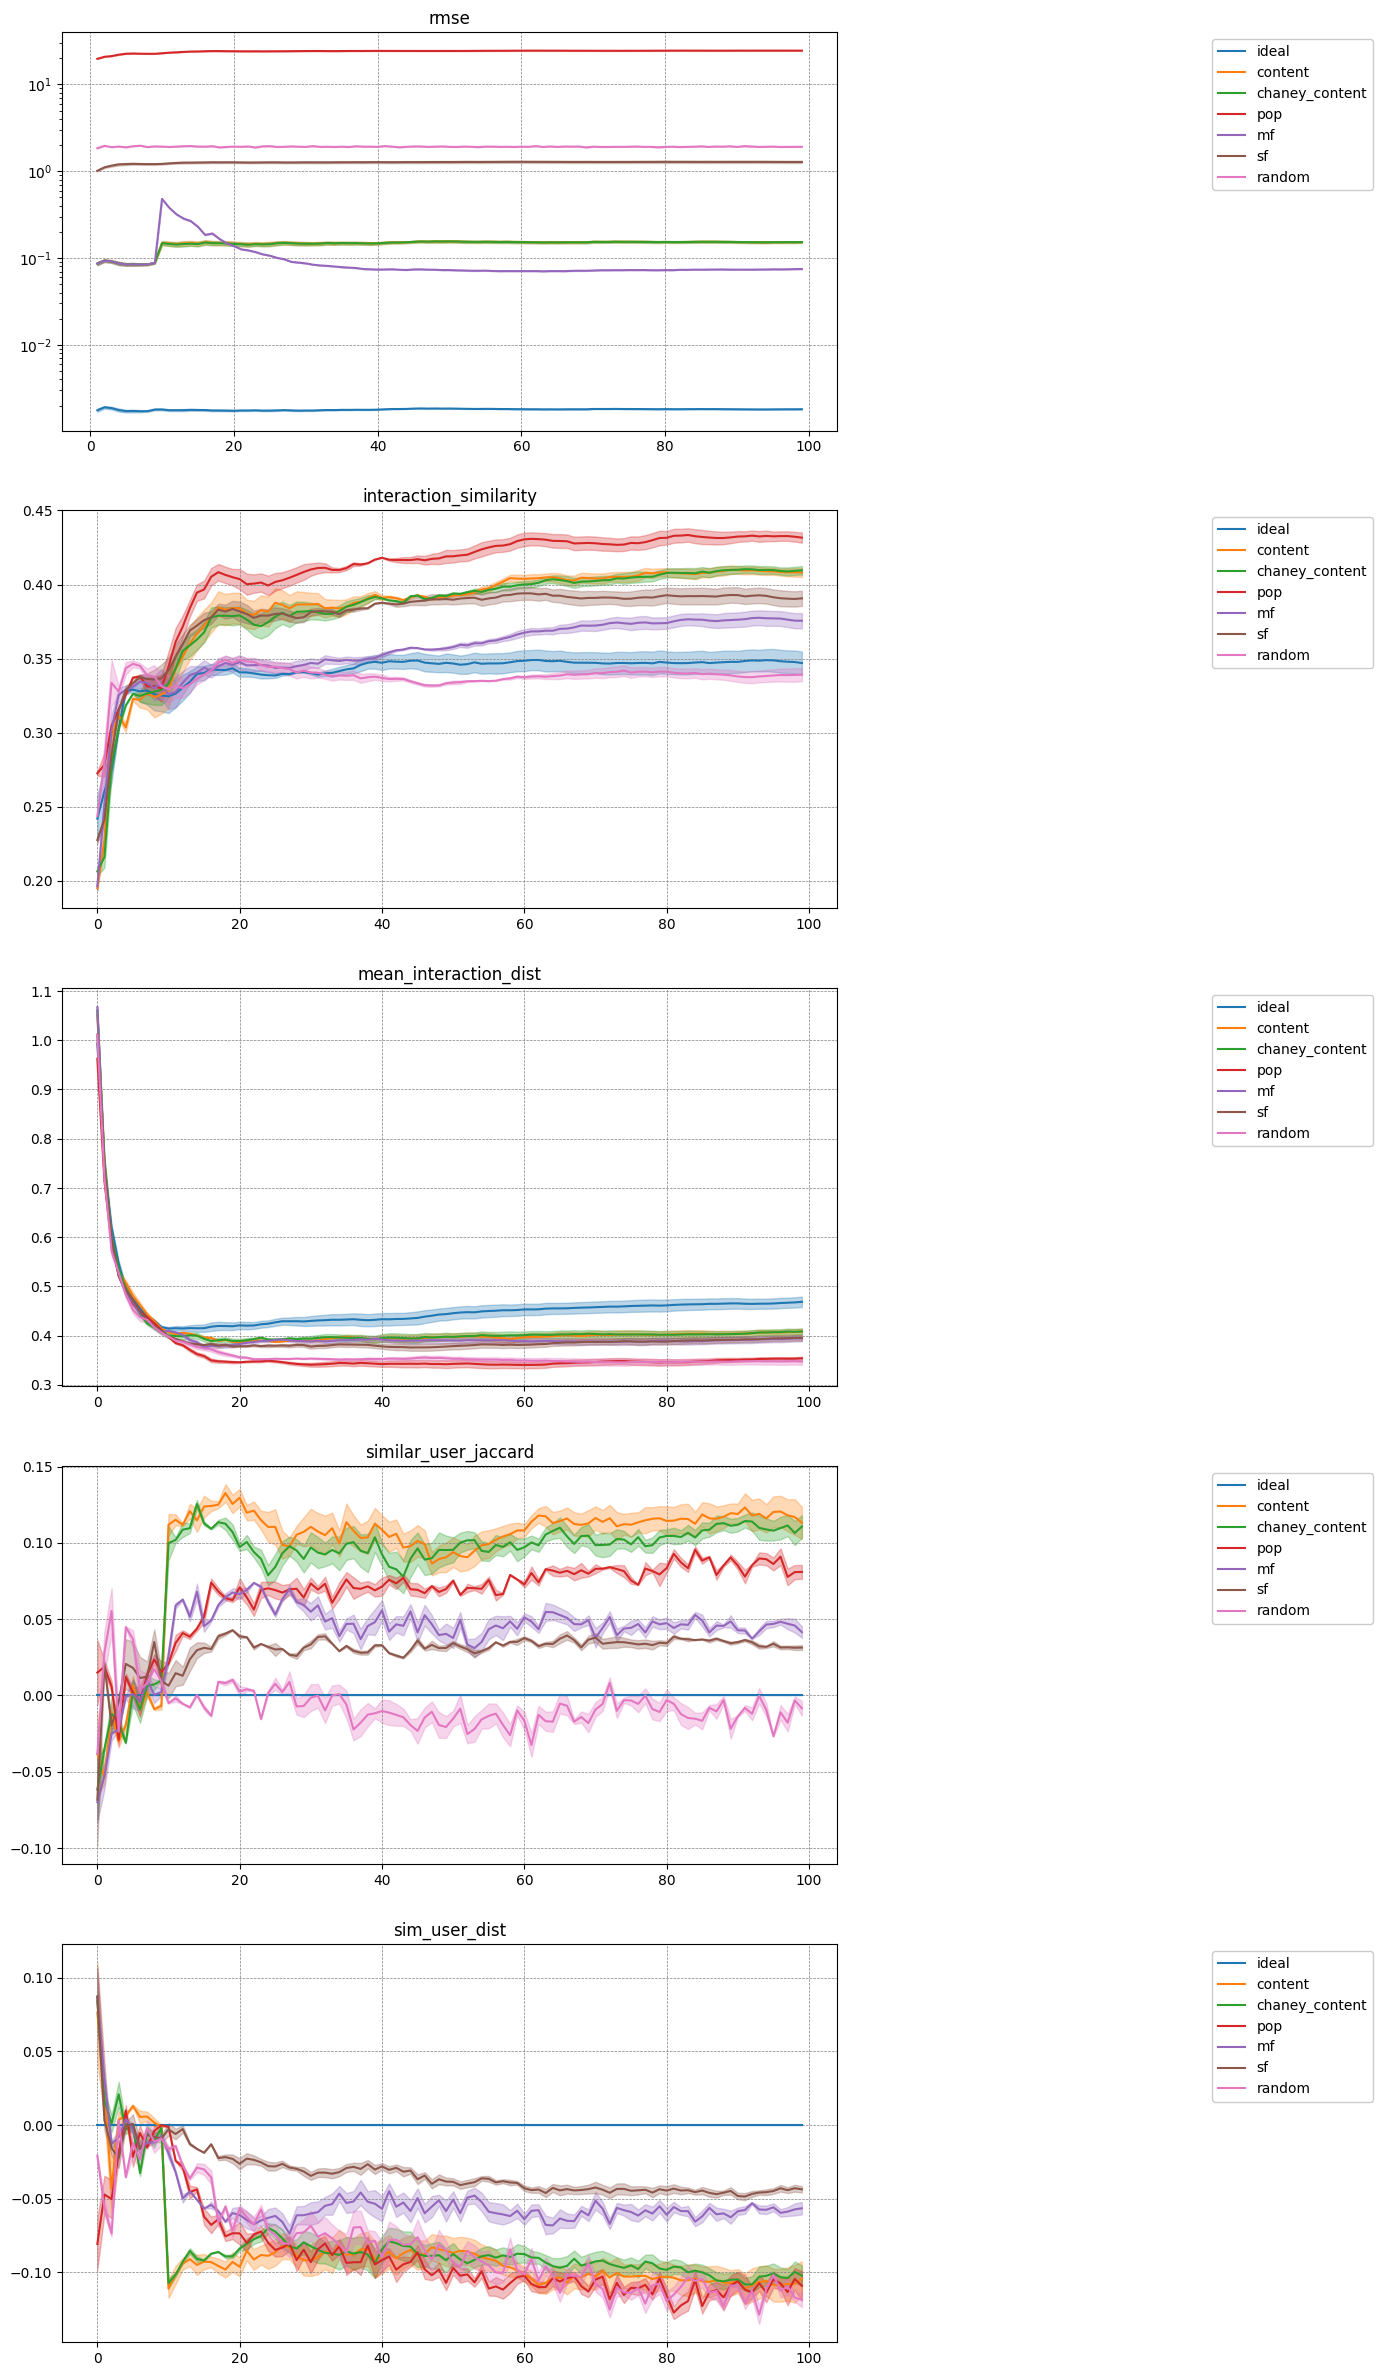

In [9]:
model_keys = ["ideal", "content", "chaney_content", "pop", "mf", "sf", "random"]
metric_list = ["rmse", "interaction_similarity", "mean_interaction_dist", "similar_user_jaccard", "sim_user_dist"]
graph_metrics_and_models(final_results, metric_list, model_keys, mult_sd=.3, relative_to_ideal=False)
#plt.ylabel("Change in Jaccard Index")
#plt.xlabel("Timestep")
plt.legend(facecolor='white', framealpha=1, loc='upper right', bbox_to_anchor=(1.7, 1.0))
#plt.xlim(0, 100)
#plt.grid()
if not DEBUG:
    plt.savefig("figures/repeated_training_sim_pair.pdf", bbox_inches = "tight")